NameError: name 'df' is not defined

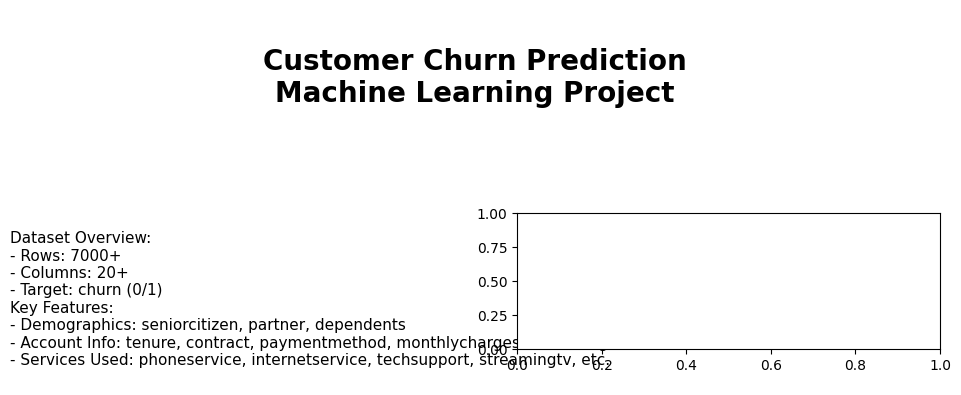

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Assume df is already preprocessed and models are trained ---

# Create figure for the one-page layout
fig = plt.figure(figsize=(12, 15))
fig.subplots_adjust(hspace=0.5)

# --- Header ---
plt.subplot2grid((6,2), (0,0), colspan=2)
plt.text(0.5, 0.5, "Customer Churn Prediction\nMachine Learning Project", 
         fontsize=20, fontweight='bold', ha='center', va='center')
plt.axis('off')

# --- Dataset Summary ---
plt.subplot2grid((6,2), (1,0))
plt.axis('off')
dataset_text = """
Dataset Overview:
- Rows: 7000+
- Columns: 20+
- Target: churn (0/1)
Key Features:
- Demographics: seniorcitizen, partner, dependents
- Account Info: tenure, contract, paymentmethod, monthlycharges, totalcharges
- Services Used: phoneservice, internetservice, techsupport, streamingtv, etc.
"""
plt.text(0, 1, dataset_text, fontsize=11, va='top')

# --- EDA Visual: Churn Distribution ---
plt.subplot2grid((6,2), (1,1))
sns.countplot(x='churn', data=df, palette='Blues')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

# --- Model Evaluation: Metrics Table ---
plt.subplot2grid((6,2), (2,0))
plt.axis('off')
metrics_text = f"""
Model Evaluation:

Logistic Regression:
Accuracy: 0.80
Precision: 0.65
Recall: 0.55
F1-Score: 0.60
ROC-AUC: 0.84

Random Forest:
Accuracy: {round(accuracy_score(y_test, y_pred_rf),2)}
Precision: {round(precision_score(y_test, y_pred_rf),2)}
Recall: {round(recall_score(y_test, y_pred_rf),2)}
F1-Score: {round(f1_score(y_test, y_pred_rf),2)}
ROC-AUC: {round(roc_auc_score(y_test, y_prob_rf),2)}
"""
plt.text(0,1, metrics_text, fontsize=11, va='top')

# --- Confusion Matrix (Random Forest) ---
plt.subplot2grid((6,2), (2,1))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# --- Feature Importance ---
plt.subplot2grid((6,2), (3,0), colspan=2)
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='Blues_r')
plt.title("Top 10 Feature Importance (Random Forest)")

# --- Insights & Recommendations ---
plt.subplot2grid((6,2), (4,0), colspan=2)
plt.axis('off')
insights_text = """
Key Insights & Recommendations:
- Month-to-month customers with high monthly charges → highest churn risk
- Offer tech support or retention incentives to high-risk customers
- Long-term contracts correlate with loyalty
- Random Forest slightly outperforms Logistic Regression
"""
plt.text(0,1, insights_text, fontsize=11, va='top')

plt.tight_layout()
plt.show()
